In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Titanic-Dataset (1).csv")

print("Dataset Loaded Successfully")
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2   

In [ ]:
#Drop only existing columns
df = df.drop(columns=[col for col in ['Name', 'Ticket', 'Cabin', 'PassengerId'] if col in df.columns])

if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].mean())

if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [ ]:
#Encoding
if 'Sex' in df.columns:
    le_sex = LabelEncoder()
    df['Sex'] = le_sex.fit_transform(df['Sex'])

if 'Embarked' in df.columns:
    le_embarked = LabelEncoder()
    df['Embarked'] = le_embarked.fit_transform(df['Embarked'])


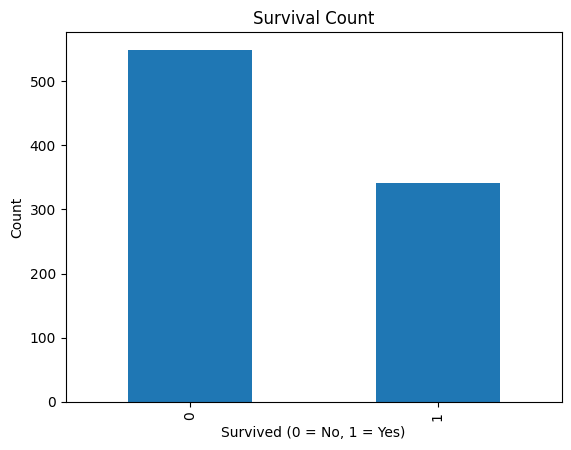

In [ ]:
#Visualization
# Survival Count
plt.figure()
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()



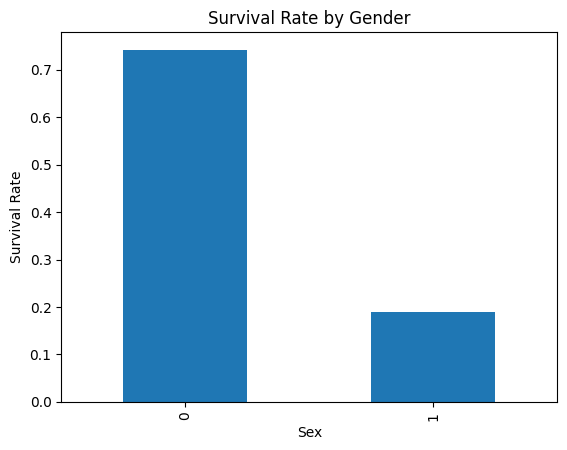

In [ ]:
# Survival by Gender (only if Sex exists)
if 'Sex' in df.columns:
    plt.figure()
    df.groupby('Sex')['Survived'].mean().plot(kind='bar')
    plt.title("Survival Rate by Gender")
    plt.xlabel("Sex")
    plt.ylabel("Survival Rate")
    plt.show()

In [ ]:
#Split Data
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
#Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
#Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.8100558659217877

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



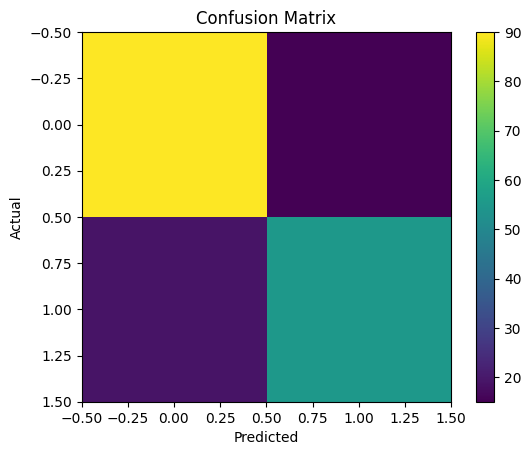

In [ ]:
#CONFUSION MATRIX VISUAL

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()